## Advanced Big Data and Data Mining 
### Lab 4: Regression Analysis with Regularization Techniques
#### Goutham Solasa

### Step 1: Data Preparation

**Importing Required Libraries**

The necessary libraries were imported for numerical operations, data handling, visualization, model building and performance evaluation. Tools for regression techniques, polynomial transformation and warning control were prepared for further analysis.

In [1]:
# Importing required libraries

# Importing numerical library
import numpy as np

# Importing data library
import pandas as pd

# Importing plotting library
import matplotlib.pyplot as plt

# Importing graph library
import seaborn as sns

# Importing diabetes data
from sklearn.datasets import load_diabetes

# Importing data splitting tool
from sklearn.model_selection import train_test_split

# Importing regression models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

# Importing polynomial tool
from sklearn.preprocessing import PolynomialFeatures

# Importing evaluation tools
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Importing warning library
import warnings

# Ignoring warning messages
warnings.filterwarnings("ignore")

**Loading Diabetes Dataset**

The diabetes dataset was loaded, and input features along with target values were separated for analysis. The dimensions of feature data and target data were shown to gain insight into the structure of the data.

In [2]:
# Loading diabetes data
diabetes = load_diabetes()

# Storing input data
X = diabetes.data

# Storing target data
y = diabetes.target

# Showing feature shape
print("Feature Shape:", X.shape)

# Showing target shape
print("Target Shape:", y.shape)

Feature Shape: (442, 10)
Target Shape: (442,)


**Creating Data Table**

The dataset features were organized into a structured table with proper column names, and target values were added for analysis. The first few rows were shown to see how the data are arranged and structured.

In [3]:
# Creating data table
df = pd.DataFrame(
    X,
    columns=diabetes.feature_names
)

# Adding target data
df["Target"] = y

# Showing first rows
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


**Dataset Information and Statistical Analysis**

The dataset information, statistical summary, and missing value details were examined to understand the data quality and distribution. Analysis validated the structure, basic statistics and missing values of the data.

In [4]:
# Showing data information
df.info()

# Showing statistical summary
df.describe()

# Checking missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  Target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
Target    0
dtype: int64

**Feature Correlation Analysis**

The correlation between different features was visualized using a heatmap to identify relationships among variables. The graphical representation was used to gain insight into the strength and direction of connections between features in the data.

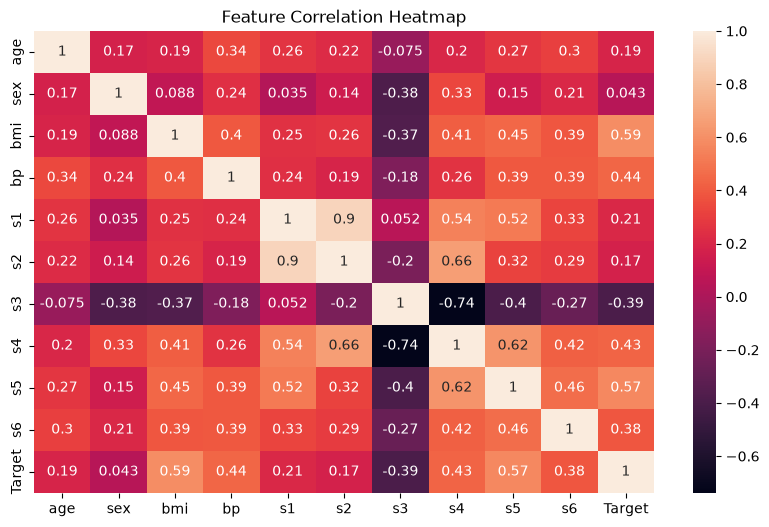

In [5]:
# Creating figure
plt.figure(figsize=(10,6))

# Creating correlation map
sns.heatmap(
    df.corr(),
    annot=True
)

# Adding chart title
plt.title(
    "Feature Correlation Heatmap"
)

# Displaying chart
plt.show()

    Relationships between features and the target variable were shown in the correlation heatmap. BMI had the strongest positive correlation with disease progression, with other features (s5 and bp) also contributing a positive score. Be familiar with key features and relationships in the data.


### Step 2: Linear Regression

**Selecting Feature and Target Variable**

The BMI feature was chosen as the independent variable, and the target column was divided for prediction analysis. The selected data were cleaned to create a simple linear regression model.


In [6]:
# Selecting BMI feature
X_linear = df[["bmi"]]

# Selecting target data
y_linear = df["Target"]

**Splitting Training and Testing Data**

Selected feature and target data were split into training and testing sets for model building and testing. The data set was divided in the ratio of 80:20 and the test set was used to assess the model's performance on unseen data.

In [7]:
# Splitting training and testing data
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_linear,
    y_linear,
    test_size=0.2,
    random_state=42
)

**Training Linear Regression Model**

The selected training data was used to create and train the linear regression model. The model was trained to learn the correlation between the BMI values and diabetes progression and used for prediction.

In [8]:
# Creating linear model
linear_model = LinearRegression()

# Training model
linear_model.fit(
    X_train_lr,
    y_train_lr
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[998.58]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['bmi']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,152
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


**Predicting Target Values**

The trained linear regression model was used to predict diabetes progression values from the testing data. The results were predicted with the objective of comparison with the actual target values to assess the performance of the model.

In [9]:
# Predicting target values
y_pred_lr = linear_model.predict(
    X_test_lr
)

**Model Performance Evaluation**

The model performance was measured using error metrics including MAE, MSE, RMSE, and R² score. These measurements were used to assess the accuracy of predictions and to gain insight into the performance of the model with test data.


In [10]:
# Creating evaluation function
def evaluate_model(actual, predicted):

    # Calculating mean absolute error
    mae = mean_absolute_error(
        actual,
        predicted
    )

    # Calculating mean squared error
    mse = mean_squared_error(
        actual,
        predicted
    )

    # Calculating root mean squared error
    rmse = np.sqrt(mse)

    # Calculating R2 score
    r2 = r2_score(
        actual,
        predicted
    )

    # Showing mean absolute error
    print("MAE :", mae)

    # Showing mean squared error
    print("MSE :", mse)

    # Showing root mean squared error
    print("RMSE:", rmse)

    # Showing R2 score
    print("R2 Score:", r2)


# Evaluating model
evaluate_model(
    y_test_lr,
    y_pred_lr
)

MAE : 52.25997644534553
MSE : 4061.8259284949268
RMSE: 63.73245584860925
R2 Score: 0.23335039815872138


**Simple Linear Regression Visualization**

The values obtained from the model were plotted and compared with the actual values to see the performance of the model by visualizing it. The graph demonstrated correlation between BMI values and disease progression, and how result values differed from predicted.

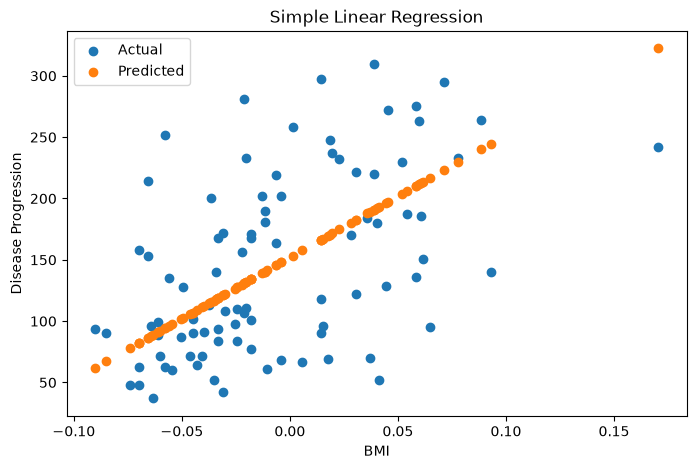

In [11]:
# Creating figure
plt.figure(figsize=(8,5))

# Creating actual data plot
plt.scatter(
    X_test_lr,
    y_test_lr,
    label="Actual"
)

# Creating predicted data plot
plt.scatter(
    X_test_lr,
    y_pred_lr,
    label="Predicted"
)

# Adding x label
plt.xlabel("BMI")

# Adding y label
plt.ylabel("Disease Progression")

# Adding chart title
plt.title(
    "Simple Linear Regression"
)

# Displaying labels
plt.legend()

# Displaying chart
plt.show()

    The graph compared actual and predicted disease progression values based on BMI. The predicted values were linear and positive, thus BMI was found to have a relationship with disease progression; however there were differences between the actual and predicted points, signifying that there were prediction errors. The general pattern was captured, but only had moderate accuracy when using one feature.

### Step 3: Multiple Regression

**Splitting Data for Multiple Regression**

The dataset was divided into training and testing sets to prepare the data for multiple regression modeling. The training data was employed to learn the model and the testing data was held back to assess the prediction performance on data not seen during training.

In [12]:
# Splitting training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Training Multiple Linear Regression Model**

The multiple regression model was created and trained using all available features from the dataset. The model learnt the relationships among multiple health measures and disease progression to better predict it.

In [13]:
# Creating multiple model
multiple_model = LinearRegression()

# Training model
multiple_model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 37.9 ,-241.96, 542.43,..., 275.32, 736.2 , 48.67]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,151.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[1.78,1.08,1. ,...,0.59,0.25,0.09]"


**Predicting Multiple Regression Values**

The predicted values of disease progression from the testing data set were generated using the trained multiple regression model. The results predicted were generated to be compared with the actual results and to test the prediction capability of the model.


In [14]:
# Predicting target values
y_pred_multiple = multiple_model.predict(
    X_test
)

**Evaluating Multiple Regression Performance**

Model performance of multiple regression model was evaluated by four statistics namely: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Square Error (RMSE), and R² scores. These evaluation measures showed the accuracy of predictions and the model’s ability to explain variations in diabetes progression.


In [15]:
# Evaluating model
evaluate_model(
    y_test,
    y_pred_multiple
)

MAE : 42.79409467959994
MSE : 2900.1936284934804
RMSE: 53.85344583676592
R2 Score: 0.4526027629719197


**Multiple Regression Prediction Visualization**

The actual and predicted disease progression values were compared using a scatter plot. The visualization provided an insight into the accuracy of the predicted values and assessed the prediction ability of the multiple regression model.

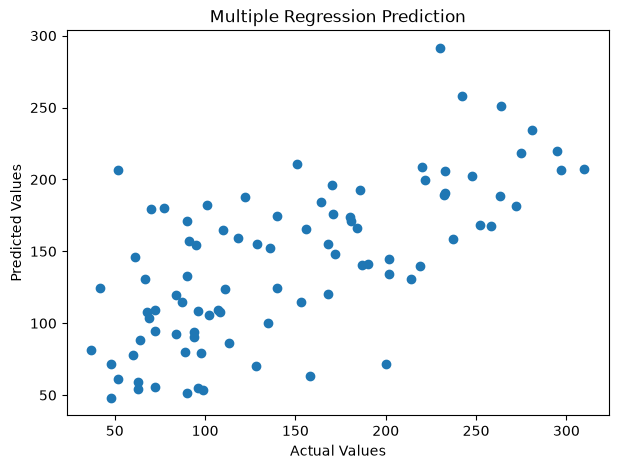

In [16]:
# Creating figure
plt.figure(figsize=(7,5))

# Creating prediction plot
plt.scatter(
    y_test,
    y_pred_multiple
)

# Adding x label
plt.xlabel(
    "Actual Values"
)

# Adding y label
plt.ylabel(
    "Predicted Values"
)

# Adding chart title
plt.title(
    "Multiple Regression Prediction"
)

# Displaying chart
plt.show()

    The scatter plot showed the relationship between the values of disease progression measured and predicted. The majority of predicted points were within a few points of the actual values, showing that the model was able to capture the general trends in the data. The prediction errors were observed in some of the variations between points, however the model worked better with multiple features than with the single feature model.

### Step 4: Polynomial Regression

**Creating Polynomial Features**

The polynomial transformation was applied to convert the original BMI feature into polynomial features of degree 2. The training data and testing data was modified to learn the non-linear relationship for polynomial regression.


In [17]:
# Creating polynomial tool
poly = PolynomialFeatures(
    degree=2
)

# Creating training polynomial data
X_train_poly = poly.fit_transform(
    X_train_lr
)

# Creating testing polynomial data
X_test_poly = poly.transform(
    X_test_lr
)

**Training Polynomial Regression Model**

The polynomial features were created and used to train the polynomial regression model. The model was able to learn the non-linear relationship between BMI values and progression of diabetes for better prediction.


In [18]:
# Creating polynomial model
poly_model = LinearRegression()

# Training model
poly_model.fit(
    X_train_poly,
    y_train_lr
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0. ,975.4,763.2]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,150.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[0.89,0.05,0. ]"


**Predicting and Evaluating Polynomial Regression Model**

The trained polynomial regression model was used to predict diabetes progression values from transformed testing data. The model performance was assessed by MAE, MSE, RMSE and R² score, which indicates the prediction accuracy and effectiveness.

In [19]:
# Predicting target values
y_pred_poly = poly_model.predict(
    X_test_poly
)

# Evaluating model
evaluate_model(
    y_test_lr,
    y_pred_poly
)

MAE : 52.38391176015265
MSE : 4085.025480871632
RMSE: 63.91420406194254
R2 Score: 0.2289715971205667


**Training and Evaluating Degree 3 Polynomial Regression Model**

The third-degree polynomial features were added to model non-linear relationships in the data that are not captured in the second degree polynomial. The importance of the transformed data was assessed by regression measures for the model trained with this data and used for prediction.

In [20]:
# Creating polynomial tool
poly3 = PolynomialFeatures(
    degree=3
)

# Creating training polynomial data
X_train_poly3 = poly3.fit_transform(
    X_train_lr
)

# Creating testing polynomial data
X_test_poly3 = poly3.transform(
    X_test_lr
)

# Creating polynomial model
poly_model3 = LinearRegression()

# Training model
poly_model3.fit(
    X_train_poly3,
    y_train_lr
)

# Predicting target values
y_pred_poly3 = poly_model3.predict(
    X_test_poly3
)

# Evaluating model
evaluate_model(
    y_test_lr,
    y_pred_poly3
)

MAE : 52.18140033344566
MSE : 4064.4433837164365
RMSE: 63.75298725327651
R2 Score: 0.23285636640090268


**Effect of Increasing Polynomial Degree on Model Performance**

Increasing the polynomial degree improved the model slightly, as the R² score increased from 0.2289 to 0.2328 and errors were reduced. While higher degree polynomial models can be fit to capture more complex patterns, too many may overfit, and too few may underfit and not learn important relationships in the data.

### Step 5: Regularization with Ridge and Lasso Regression

**Training Ridge and Lasso Regression Models**

A Ridge and Lasso regression models were developed and implemented with the features that were extracted from the data set. To keep the model simple, avoid overfitting and to improve the predictability, regularization techniques were used.


In [21]:
# Importing regression models
from sklearn.linear_model import Ridge, Lasso

# Creating ridge model
ridge_model = Ridge(alpha=1.0)

# Training ridge model
ridge_model.fit(
    X_train,
    y_train
)

# Creating lasso model
lasso_model = Lasso(alpha=0.1)

# Training lasso model
lasso_model.fit(
    X_train,
    y_train
)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


**Predicting and Evaluating Ridge and Lasso Models**

The Ridge and Lasso models were used to predict diabetes progression values from testing data. To compare the prediction accuracy and regularization effects of the model performances, MAE, MSE, RMSE and R² score have been used.

In [22]:
# Predicting ridge values
y_pred_ridge = ridge_model.predict(
    X_test
)

# Predicting lasso values
y_pred_lasso = lasso_model.predict(
    X_test
)

# Creating evaluation function
def evaluate_model(actual, predicted):

    # Showing mean absolute error
    print("MAE :", mean_absolute_error(actual, predicted))

    # Showing mean squared error
    print("MSE :", mean_squared_error(actual, predicted))

    # Showing root mean squared error
    print("RMSE :", np.sqrt(mean_squared_error(actual, predicted)))

    # Showing R2 score
    print("R² Score :", r2_score(actual, predicted))

# Showing ridge results
print("Ridge Regression Performance")

# Evaluating ridge model
evaluate_model(y_test, y_pred_ridge)

# Showing lasso results
print("\nLasso Regression Performance")

# Evaluating lasso model
evaluate_model(y_test, y_pred_lasso)

Ridge Regression Performance
MAE : 46.13885766697452
MSE : 3077.41593882723
RMSE : 55.47446204180109
R² Score : 0.41915292635986545

Lasso Regression Performance
MAE : 42.85442771664998
MSE : 2798.1934851697188
RMSE : 52.897953506442185
R² Score : 0.4718547867276227


**Analyzing Ridge Regression Alpha Values**

Different alpha values were tested to understand the effect of regularization strength on Ridge Regression performance. The R2 values for each alpha was determined to pinpoint the effect of varying degrees of regularization on the accuracy and complexity of the model.

In [23]:
# Creating alpha values
alpha_values = [0.01, 0.1, 1, 10, 100]

# Running each alpha value
for alpha in alpha_values:

    # Creating ridge model
    ridge = Ridge(alpha=alpha)

    # Training ridge model
    ridge.fit(
        X_train,
        y_train
    )

    # Predicting target values
    prediction = ridge.predict(
        X_test
    )

    # Showing alpha value
    print("Alpha:", alpha)

    # Showing R2 score
    print(
        "R² Score:",
        r2_score(y_test, prediction)
    )

    # Showing separator
    print("----------------")

Alpha: 0.01
R² Score: 0.4559819504579109
----------------
Alpha: 0.1
R² Score: 0.46085219464119254
----------------
Alpha: 1
R² Score: 0.41915292635986545
----------------
Alpha: 10
R² Score: 0.161225867509881
----------------
Alpha: 100
R² Score: 0.012171803489062438
----------------


**Comparing Ridge and Lasso Regression Performance**

The performance comparison table has been designed to analyse the results obtained from Ridge and Lasso regression using the MAE, RMSE and R² score as metrics. Through the comparison, the differences between the prediction accuracy were identified and the influence of various regularization methods on the performance of the model was found out.

In [24]:
# Creating comparison table
comparison = pd.DataFrame({

    # Adding model names
    "Model":[
        "Ridge Regression",
        "Lasso Regression"
    ],

    # Adding mean absolute error
    "MAE":[
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso)
    ],

    # Adding root mean squared error
    "RMSE":[
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    ],

    # Adding R2 score
    "R² Score":[
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]

})

# Showing comparison table
comparison

,Model,MAE,RMSE,R² Score
0,Ridge Regression,46.138858,55.474462,0.419153
1,Lasso Regression,42.854428,52.897954,0.471855


    The comparison showed that Lasso Regression performed better than Ridge Regression with lower MAE (42.85), lower RMSE (52.89), and higher R² score (0.47). This suggested that the Lasso model was more accurate in predicting and it also performed well with feature selection whereas Ridge also reduced the chances of overfitting and made the model more stable.


**Ridge and Lasso Prediction Visualization**

The scatter plot compared actual values with predictions from Ridge and Lasso regression models. Both models had similar prediction patterns, however, Lasso predictions were closer to the actual values, which means they were more performing and had better accuracy, than Ridge Regression.

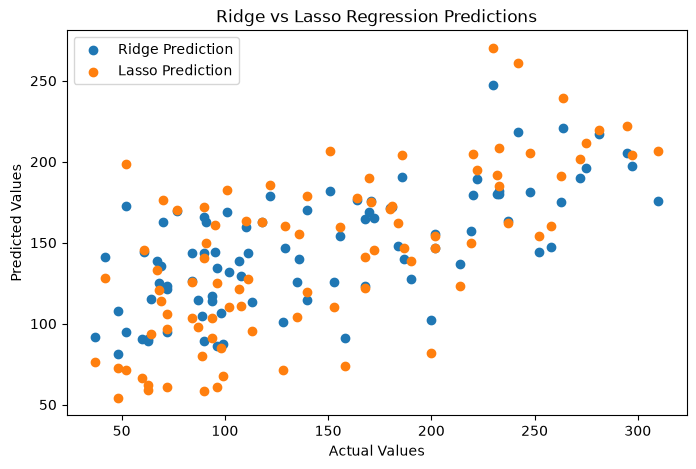

In [25]:
# Creating figure
plt.figure(figsize=(8,5))

# Creating ridge prediction plot
plt.scatter(
    y_test,
    y_pred_ridge,
    label="Ridge Prediction"
)

# Creating lasso prediction plot
plt.scatter(
    y_test,
    y_pred_lasso,
    label="Lasso Prediction"
)

# Adding x label
plt.xlabel("Actual Values")

# Adding y label
plt.ylabel("Predicted Values")

# Adding chart title
plt.title(
    "Ridge vs Lasso Regression Predictions"
)

# Displaying labels
plt.legend()

# Displaying chart
plt.show()

    The plot compared the predicted values of Ridge and Lasso Regression with actual disease progression values. Both models exhibited a similar positive trend with an increase in the values, suggesting a positive relationship between the actual and predicted values. Lasso predictions seemed to be a bit closer to the actual values, and again showed better prediction performance than Ridge Regression.

### Step 6: Model Comparison and Analysis

**Comparing Regression Model Performance**

The performance comparison table was created to evaluate different regression models using MAE, RMSE, and R² score metrics. The results were used to determine the model whose prediction accuracy is better and to compare the effect of the regularization methods on the prediction accuracy.

In [26]:
# Creating comparison table
model_comparison = pd.DataFrame({

    # Adding model names
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],

    # Adding mean absolute error
    "MAE": [

        mean_absolute_error(y_test_lr, y_pred_lr),

        mean_absolute_error(y_test, y_pred_multiple),

        mean_absolute_error(y_test_lr, y_pred_poly),

        mean_absolute_error(y_test, y_pred_ridge),

        mean_absolute_error(y_test, y_pred_lasso)

    ],

    # Adding root mean squared error
    "RMSE": [

        np.sqrt(mean_squared_error(y_test_lr, y_pred_lr)),

        np.sqrt(mean_squared_error(y_test, y_pred_multiple)),

        np.sqrt(mean_squared_error(y_test_lr, y_pred_poly)),

        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),

        np.sqrt(mean_squared_error(y_test, y_pred_lasso)

    )],

    # Adding R2 score
    "R² Score": [

        r2_score(y_test_lr, y_pred_lr),

        r2_score(y_test, y_pred_multiple),

        r2_score(y_test_lr, y_pred_poly),

        r2_score(y_test, y_pred_ridge),

        r2_score(y_test, y_pred_lasso)

    ]

})

# Showing comparison table
model_comparison

,Model,MAE,RMSE,R² Score
0,Simple Linear Regression,52.259976,63.732456,0.233350
1,Multiple Linear Regression,42.794095,53.853446,0.452603
2,Polynomial Regression,52.383912,63.914204,0.228972
3,Ridge Regression,46.138858,55.474462,0.419153
4,Lasso Regression,42.854428,52.897954,0.471855


    The comparison showed that Lasso Regression achieved the best performance with the highest R² score (0.4718) and lowest RMSE (52.89), indicating better prediction accuracy. Multiple Linear Regression also achieved good results using all the features, whereas Simple Linear and Polynomial Regression exhibited lower performance, possibly due to limited feature use and potential model complexity. Regularization techniques enhanced model stability and helped to minimize overfitting.

**Regression Model Performance Visualization**

The bar chart compared the R² scores of different regression models to identify the best-performing approach. Lasso Regression model gave the highest R2 value followed by Multiple Linear Regression model and thus exhibited better predictability than Simple linear and Polynomial regression. The results showed that regularization played an useful role on improving the performance and reliability of models.

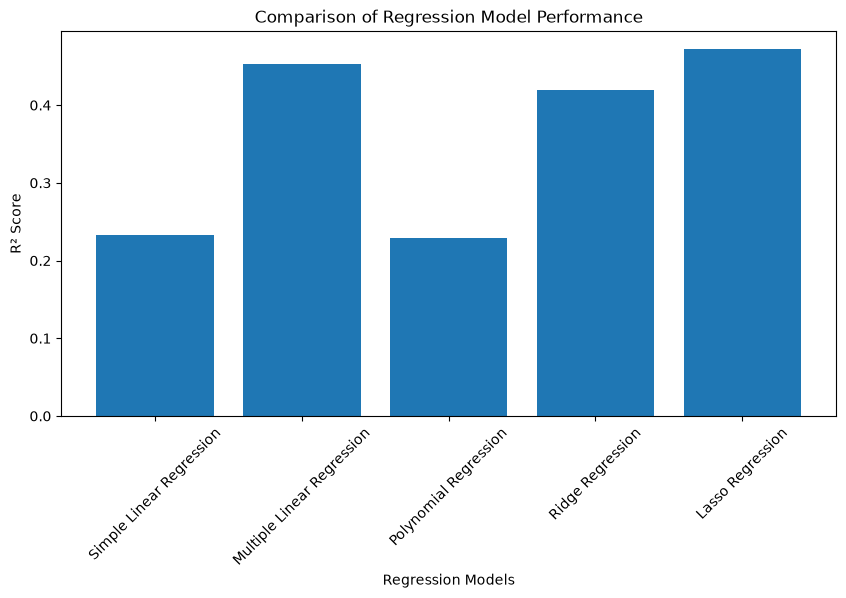

In [27]:
# Creating figure
plt.figure(figsize=(10,5))

# Creating bar chart
plt.bar(
    model_comparison["Model"],
    model_comparison["R² Score"]
)

# Rotating x labels
plt.xticks(
    rotation=45
)

# Adding x label
plt.xlabel(
    "Regression Models"
)

# Adding y label
plt.ylabel(
    "R² Score"
)

# Adding chart title
plt.title(
    "Comparison of Regression Model Performance"
)

# Displaying chart
plt.show()

    The bar chart compared the R² scores of all regression models used for diabetes progression prediction. Lasso Regression showed the best performance followed by Multiple Linear Regression and Ridge Regression which also showed good performance in prediction ability. Simple Linear Regression and Polynomial Regression achieved lower scores of R² which indicated that the performance of the models was improved by using multiple features and regularization techniques.

**RMSE Comparison of Regression Models**

The RMSE values for the various regression models were compared in the bar chart with the lower RMSE value representing the better prediction accuracy. The RMSE value for Lasso Regression was found to be minimum with Multiple Linear Regression and for Simple Linear and Polynomial regression, it was higher. The findings indicated that application of regularization techniques was beneficial to the model performance with respect to reductions in prediction errors.


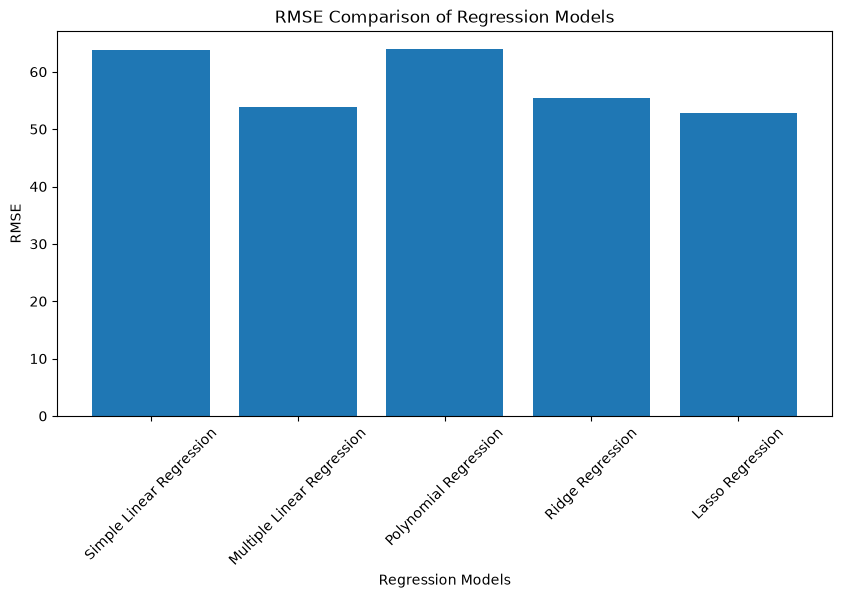

In [28]:
# Creating figure
plt.figure(figsize=(10,5))

# Creating bar chart
plt.bar(
    model_comparison["Model"],
    model_comparison["RMSE"]
)

# Rotating x labels
plt.xticks(
    rotation=45
)

# Adding x label
plt.xlabel(
    "Regression Models"
)

# Adding y label
plt.ylabel(
    "RMSE"
)

# Adding chart title
plt.title(
    "RMSE Comparison of Regression Models"
)

# Displaying chart
plt.show()

    The RMSE comparison showed the prediction error levels of different regression models, where lower RMSE indicated better performance. Lasso Regression gave the minimum RMSE followed by Multiple Linear Regression and Ridge Regression which were more accurate in terms of prediction. The errors of Simple Linear Regression and Polynomial Regression were higher, meaning that these models were less effective in predicting the data.

**Performance Analysis of Regression Models**

The Simple Linear Regression model provided a basic prediction using only the BMI feature. It demonstrated reduced performance due to the need for multiple features to model the complex relationships in the progression of diabetes.

The Multiple Linear Regression model yielded better results, utilizing all of the available health-related features. This was achieved because of multiple factors taken into consideration together for estimating disease progression, which resulted in high accuracy in prediction.

The Polynomial Regression model was able to capture non-linear patterns in the data, but the improvement was limited. As the degree of the polynomial increased, the model became more complex and there was the potential for overfitting without much increase in model performance.

The Ridge Regression model improved model stability by applying L2 regularization. It suppressed the effect of large coefficients, and helped to suppress overfitting without lowering the prediction performance.

The Lasso Regression model achieved the best overall performance with the highest R² score and lowest RMSE value. It reduced the less important effects of features and provided feature selection which increased the accuracy of prediction.


**Overfitting Handling and Model Improvement**

The higher degree polynomial regressions could overfit the data and gain more complex patterns from the training data that will not generalize to new data. Models with lower degrees of polynomials can also be underfitting because it cannot model important relationships. Ridge and Lasso regularization techniques were used to prevent overfitting by controlling the complexity of the model. Ridge forced large coefficient values to become smaller, and Lasso forced less important features to be removed, made some coefficient value equal to 0. The regularized models provided better balance between accuracy and generalization compared to basic regression models.


**Insights Gained from Diabetes Dataset**

The Diabetes data set had several health indicators that affected the disease process. It was observed from the analysis that, the use of more than one feature gave better prediction than just using one feature. BMI was significantly associated with disease progression and other medical measurements also helped to predict the disease progression. None of the individual characteristics alone could fully account for the progression of diabetes. The results demonstrated that regression models using multiple variables and regularization techniques were more effective for predicting disease outcomes and handling complex relationships within the dataset.

### Key Insights Gained from Regression Analysis

The analysis showed that using multiple health-related features provided better prediction results compared to using only one feature. BMI was a good predictor of diabetes prognosis, and other clinical measures added to performance. The comparative analysis of regression models revealed that Lasso Regression's performance was optimized by reducing the effect of unnecessary features and Ridge Regression's performance was optimized by controlling the coefficient values in the model. Regularization methods were used to prevent overfitting and enhance the models' performance on unseen data. It was shown that model selection and parameter tuning was important to improve the prediction accuracy in the experiment. Each of the regression methods had a different benefit based on the complexity of the model and the nature of the dataset.

### Challenges Faced and Decisions Made During the Lab

A challenge was choosing the appropriate features and comprehending how the input variables relate to the progression of diabetes. Correlation analysis has been done for important features and to understand the feature relationship. Another challenge was handling the complexity of the model in Polynomial Regression because if the polynomial degree was high, this would lead to better learning but also potentially to overfitting. Model performance was observed for different degrees of the polynomials. Regularization parameters (alpha values) were adjusted for Ridge and Lasso Regression to find a balance between reducing overfitting and maintaining prediction accuracy. Models were compared and the best-performing methodology was selected based on the evaluation metrics: MAE, RMSE and R2 score.